# XAI for fake news classification



## 2. Environment & Dependencies

In [2]:
!pip install -q numpy pandas matplotlib seaborn scikit-learn xgboost lightgbm nltk torch transformers

In [3]:
import re
import warnings
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords as nltk_stopwords
from nltk.stem.porter import PorterStemmer

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score,
    log_loss, classification_report, confusion_matrix,
)

from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoTokenizer, AutoModel

nltk.download('stopwords', quiet=True)
STOPWORDS = set(nltk_stopwords.words('english'))

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Auto-detect GPU; fall back to CPU. Used by both the LSTM (Section 7)
# and DistilBERT (Section 8). Defined here so it's available throughout the notebook.
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'Using GPU: {gpu_name}  ({gpu_mem:.1f} GiB)')
else:
    DEVICE = torch.device('cpu')
    print('No CUDA GPU detected; using CPU.')

sns.set_theme(style='whitegrid')

No CUDA GPU detected; using CPU.


## 3. Dataset

### 3.1 Source

The WELFake dataset merges several public fake-news corpora into a single labelled collection. Each row contains a `title`, a `text` body, and a binary `label` (0 = real, 1 = fake). The CSV file is expected to be present in the working directory.

In [4]:
DATASET_PATH = 'WELFake_Dataset.csv'
df = pd.read_csv(DATASET_PATH)
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
df.head()

Rows: 72,134
Columns: 4


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


### 3.2 Schema & Basic Statistics

In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB


,Unnamed: 0,label
count,72134.000000,72134.000000
mean,36066.500000,0.514404
std,20823.436496,0.499796
min,0.000000,0.000000
25%,18033.250000,0.000000
50%,36066.500000,1.000000
75%,54099.750000,1.000000
max,72133.000000,1.000000


## 4. Exploratory Data Analysis

### 4.1 Class Balance

C:\Users\Admin\AppData\Local\Temp\ipykernel_3476\2612813969.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=df, palette='Set2')
C:\Users\Admin\AppData\Local\Temp\ipykernel_3476\2612813969.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Real (0)', 'Fake (1)'])


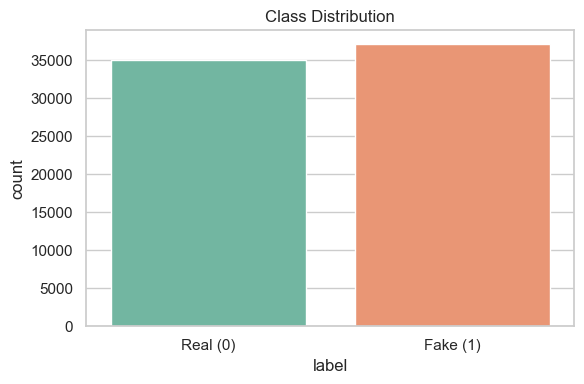

label
1    0.514
0    0.486
Name: proportion, dtype: float64

In [6]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='label', data=df, palette='Set2')
ax.set_xticklabels(['Real (0)', 'Fake (1)'])
ax.set_title('Class Distribution')
plt.tight_layout()
plt.show()

df['label'].value_counts(normalize=True).round(3)

### 4.2 Word-Count Distribution

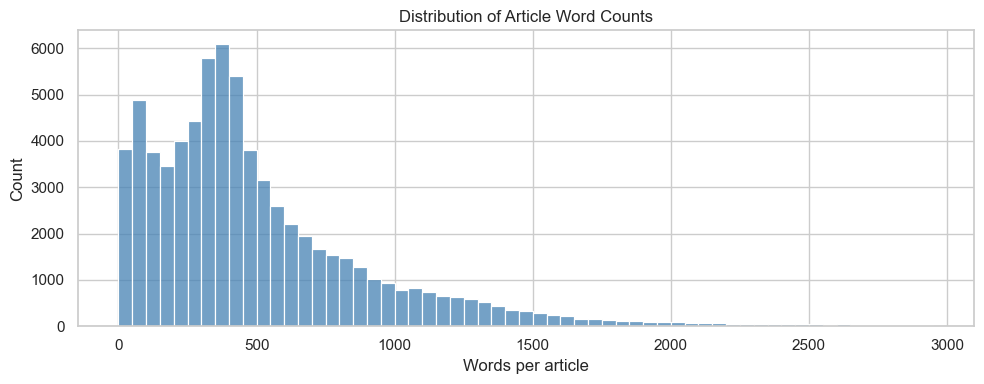

In [7]:
df['num_words'] = df['text'].fillna('').apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 4))
sns.histplot(df['num_words'], bins=range(0, 3000, 50), color='steelblue')
plt.title('Distribution of Article Word Counts')
plt.xlabel('Words per article')
plt.tight_layout()
plt.show()

### 4.3 Sample Articles

In [8]:
print('--- Sample REAL articles ---')
print(df[df['label'] == 0]['title'].dropna().sample(3, random_state=RANDOM_STATE).to_string(index=False))
print()
print('--- Sample FAKE articles ---')
print(df[df['label'] == 1]['title'].dropna().sample(3, random_state=RANDOM_STATE).to_string(index=False))

--- Sample REAL articles ---
Two People Die after Eating Raw-Milk Cheese Mad...
DUP blames Sinn Fein for Northern Ireland talks...
Exclusive: Former top Brazil prosecutor says su...

--- Sample FAKE articles ---
Congress: Hillary Will Be Impeached If She Beco...
CHECK OUT TINY CROWD At Hillary Rally In MUST W...
Should Third Parties Support ‘Vote Pacts’ To Av...


## 5. Data Preprocessing

### 5.1 Missing Values

In [9]:
print('Missing values per column:')
print(df.isnull().sum())

df = df.dropna(subset=['title', 'text', 'label']).reset_index(drop=True)
df = df.drop(columns=[c for c in df.columns if c.startswith('Unnamed')], errors='ignore')
print(f'\nAfter dropping rows with missing title/text: {df.shape[0]:,} rows')

Missing values per column:
Unnamed: 0      0
title         558
text           39
label           0
num_words       0
dtype: int64

After dropping rows with missing title/text: 71,537 rows


### 5.2 Deduplication

In [10]:
dup_count = df.duplicated().sum()
print(f'Duplicate rows: {dup_count:,}')
df = df.drop_duplicates().reset_index(drop=True)
print(f'After deduplication: {df.shape[0]:,} rows')

Duplicate rows: 8,416
After deduplication: 63,121 rows


### 5.3 Text Cleaning

A standard cleaning pipeline is applied to both the title and the body:

- Strip HTML tags, URLs, digits, and punctuation
- Lowercase
- Tokenize, remove English stopwords, and apply Porter stemming
- Collapse repeated whitespace and repeated characters

In [11]:
ps = PorterStemmer()

def cleaning(text: str) -> str:
    text = re.sub(r'<.*?>', '', text)
    text = text.lower()
    text = re.sub(r'_+', ' ', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+[a-zA-Z]\s+', ' ', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [ps.stem(w) for w in words if w not in STOPWORDS]
    words = [re.sub(r'(.)\1{2,}', r'\1\1', w) for w in words]
    cleaned = ' '.join(words)
    cleaned = re.sub(r'\b(\w+)( \1\b)+', r'\1', cleaned)
    return cleaned

for col in ['title', 'text']:
    df[f'{col}_clean'] = df[col].astype(str).apply(cleaning)

df[['title', 'title_clean', 'text_clean']].head(3)

,title,title_clean,text_clean
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,law enforc high alert follow threat cop white ...,comment expect barack obama member fyf fukyofl...
1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,unbeliev obama attorney gener say charlott rio...,demonstr gather last night exercis constitut p...
2,"Bobby Jindal, raised Hindu, uses story of Chri...",bobbi jindal rais hindu use stori christian co...,dozen polit activ pastor came privat dinner fr...


### 5.4 Combining Title and Body

The cleaned title and body are concatenated to give the classical models both signals. The original (uncleaned) concatenation is also stored for the transformer pipeline, which performs its own tokenization and benefits from the natural-language form.

In [12]:
df['combined_clean'] = df['title_clean'] + ' ' + df['text_clean']
df['combined_raw']   = df['title'].astype(str) + ' ' + df['text'].astype(str)
df[['combined_clean', 'combined_raw']].head(2)

,combined_clean,combined_raw
0,law enforc high alert follow threat cop white ...,LAW ENFORCEMENT ON HIGH ALERT Following Threat...
1,unbeliev obama attorney gener say charlott rio...,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...


### 5.5 Train / Test Split

A stratified **80 / 20** split with a fixed random state is used throughout the notebook so that every model is trained on the same 80 % of articles and evaluated on the same 20 % held-out test set.

In [13]:
le = LabelEncoder()
y_encoded = le.fit_transform(df['label'])

# 80 / 20 stratified train/test split.
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['combined_clean'].values, y_encoded,
    test_size=0.20, random_state=RANDOM_STATE, stratify=y_encoded,
)

# Parallel split on the raw (uncleaned) text for the transformer pipeline.
# Same seed -> identical indices, so train/test contain the same articles.
X_train_raw, X_test_raw, _, _ = train_test_split(
    df['combined_raw'].values, y_encoded,
    test_size=0.20, random_state=RANDOM_STATE, stratify=y_encoded,
)

print(f'Train: {len(X_train_text):,}  Test: {len(X_test_text):,}')

Train: 50,496  Test: 12,625


## 6. Classical Machine Learning Baselines

### 6.1 TF-IDF Vectorization

In [14]:
tfidf = TfidfVectorizer(
    max_df=0.90,
    min_df=2,
    max_features=5000,
    stop_words='english',
)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)
print(f'TF-IDF train: {X_train_tfidf.shape}  test: {X_test_tfidf.shape}')

TF-IDF train: (50496, 5000)  test: (12625, 5000)


### 6.2 Evaluation Helpers

Two small helpers used throughout this section:

- `evaluate_classifier(name, model, ...)` - fits the model, evaluates train/test accuracy, F1, precision, recall, and ROC-AUC, prints a per-class `classification_report`, and returns a metrics dict plus the per-split predictions. Accepts optional `fit_params` so models that support per-iteration tracking (XGBoost, LightGBM) can pass `eval_set` through the same code path.
- `plot_acc_loss_curves(name, x, accs, losses, xlabel)` - draws the standard 2-panel accuracy + loss figure with Training and Testing lines.
- `_collect_classical_curve(...)` - small utility used by Logistic Regression and Random Forest to sweep a hyperparameter (e.g. `max_iter`, `n_estimators`) and record per-step train/test accuracy and log-loss.

**Methodology note on the per-iteration curves below**: the test curve is plotted purely as a diagnostic. The test set is never used to select hyperparameters or stopping points - the headline numbers in the final comparison table come from a single evaluation of the chosen model.

In [15]:
def evaluate_classifier(name, model, X_tr, y_tr, X_te, y_te, fit_params=None):
    """Fit, evaluate on train and test, print report, return (metrics_dict, preds_dict).

    `fit_params` lets callers pass eval_set, callbacks, etc. to model.fit().
    """
    if fit_params is None:
        fit_params = {}
    model.fit(X_tr, y_tr, **fit_params)
    preds = {
        'train': model.predict(X_tr),
        'test':  model.predict(X_te),
    }
    metrics = {
        'Model':     name,
        'TrainAcc':  accuracy_score(y_tr,  preds['train']),
        'TestAcc':   accuracy_score(y_te,  preds['test']),
        'F1':        f1_score(y_te,         preds['test']),
        'Precision': precision_score(y_te,  preds['test']),
        'Recall':    recall_score(y_te,     preds['test']),
    }
    if hasattr(model, 'predict_proba'):
        prob = model.predict_proba(X_te)[:, 1]
        metrics['ROC-AUC'] = roc_auc_score(y_te, prob)
    else:
        metrics['ROC-AUC'] = float('nan')

    print(f'=== {name} ===')
    print(f'Train acc: {metrics["TrainAcc"]:.4f}  |  Test acc: {metrics["TestAcc"]:.4f}')
    print(f'Test F1: {metrics["F1"]:.4f}  Precision: {metrics["Precision"]:.4f}  Recall: {metrics["Recall"]:.4f}  ROC-AUC: {metrics["ROC-AUC"]:.4f}')
    print()
    print(classification_report(y_te, preds['test'], target_names=['Real', 'Fake']))
    return metrics, preds

In [16]:
def plot_acc_loss_curves(name, x, accs, losses, xlabel='Epoch'):
    """2-panel accuracy + loss figure. `accs` and `losses` are dicts with
    keys 'train' and 'test'.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    palette   = {'train': '#1f77b4', 'test': '#ff7f0e'}
    label_map = {'train': 'Training', 'test': 'Testing'}
    for split in ('train', 'test'):
        axes[0].plot(x, accs[split],   '-o', label=label_map[split], color=palette[split])
        axes[1].plot(x, losses[split], '-o', label=label_map[split], color=palette[split])
    axes[0].set_title(f'{name} \u2014 Accuracy')
    axes[0].set_xlabel(xlabel); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].set_title(f'{name} \u2014 Loss')
    axes[1].set_xlabel(xlabel); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()


def _collect_classical_curve(model_factory, sweep, refit_each=True, warm_start_obj=None):
    """Sweep a hyperparameter, recording accuracy + log-loss on train/test at each step."""
    accs   = {'train': [], 'test': []}
    losses = {'train': [], 'test': []}
    for v in sweep:
        if refit_each:
            m = model_factory(v)
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                m.fit(X_train_tfidf, y_train)
        else:
            warm_start_obj.n_estimators = v
            warm_start_obj.fit(X_train_tfidf, y_train)
            m = warm_start_obj
        for split, X, y in [('train', X_train_tfidf, y_train),
                            ('test',  X_test_tfidf,  y_test)]:
            proba = m.predict_proba(X)
            preds = (proba[:, 1] >= 0.5).astype(int)
            accs[split].append(accuracy_score(y, preds))
            losses[split].append(log_loss(y, proba, labels=[0, 1]))
    return accs, losses

### 6.3 Logistic Regression

In [17]:
lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_metrics, lr_preds = evaluate_classifier(
    'Logistic Regression', lr_model,
    X_train_tfidf, y_train, X_test_tfidf, y_test,
)
y_pred_lr = lr_preds['test']

=== Logistic Regression ===
Train acc: 0.9533  |  Test acc: 0.9434
Test F1: 0.9370  Precision: 0.9365  Recall: 0.9375  ROC-AUC: 0.9857

              precision    recall  f1-score   support

        Real       0.95      0.95      0.95      6959
        Fake       0.94      0.94      0.94      5666

    accuracy                           0.94     12625
   macro avg       0.94      0.94      0.94     12625
weighted avg       0.94      0.94      0.94     12625



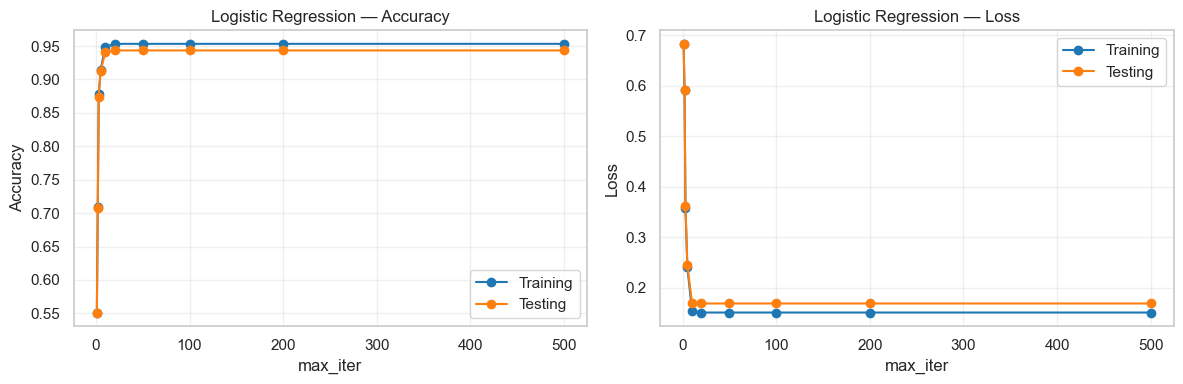

In [18]:
lr_iters = [1, 2, 3, 5, 10, 20, 50, 100, 200, 500]
lr_curve_accs, lr_curve_losses = _collect_classical_curve(
    lambda n: LogisticRegression(max_iter=n, random_state=RANDOM_STATE, n_jobs=-1),
    lr_iters,
)
plot_acc_loss_curves(
    'Logistic Regression', lr_iters,
    lr_curve_accs, lr_curve_losses,
    xlabel='max_iter',
)

### 6.4 Random Forest

In [19]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_metrics, rf_preds = evaluate_classifier(
    'Random Forest', rf_model,
    X_train_tfidf, y_train, X_test_tfidf, y_test,
)
y_pred_rf = rf_preds['test']

=== Random Forest ===
Train acc: 1.0000  |  Test acc: 0.9380
Test F1: 0.9306  Precision: 0.9342  Recall: 0.9271  ROC-AUC: 0.9848

              precision    recall  f1-score   support

        Real       0.94      0.95      0.94      6959
        Fake       0.93      0.93      0.93      5666

    accuracy                           0.94     12625
   macro avg       0.94      0.94      0.94     12625
weighted avg       0.94      0.94      0.94     12625



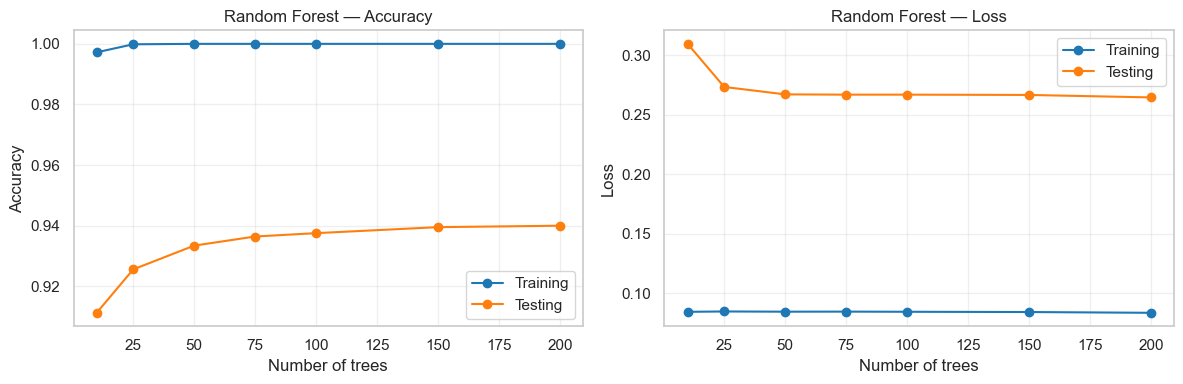

In [20]:
rf_steps = [10, 25, 50, 75, 100, 150, 200]
rf_warm = RandomForestClassifier(
    n_estimators=rf_steps[0], random_state=RANDOM_STATE,
    n_jobs=-1, warm_start=True,
)
rf_curve_accs, rf_curve_losses = _collect_classical_curve(
    model_factory=None, sweep=rf_steps,
    refit_each=False, warm_start_obj=rf_warm,
)
plot_acc_loss_curves(
    'Random Forest', rf_steps,
    rf_curve_accs, rf_curve_losses,
    xlabel='Number of trees',
)

### 6.5 XGBoost

=== XGBoost ===
Train acc: 0.9816  |  Test acc: 0.9548
Test F1: 0.9503  Precision: 0.9381  Recall: 0.9628  ROC-AUC: 0.9917

              precision    recall  f1-score   support

        Real       0.97      0.95      0.96      6959
        Fake       0.94      0.96      0.95      5666

    accuracy                           0.95     12625
   macro avg       0.95      0.96      0.95     12625
weighted avg       0.96      0.95      0.95     12625



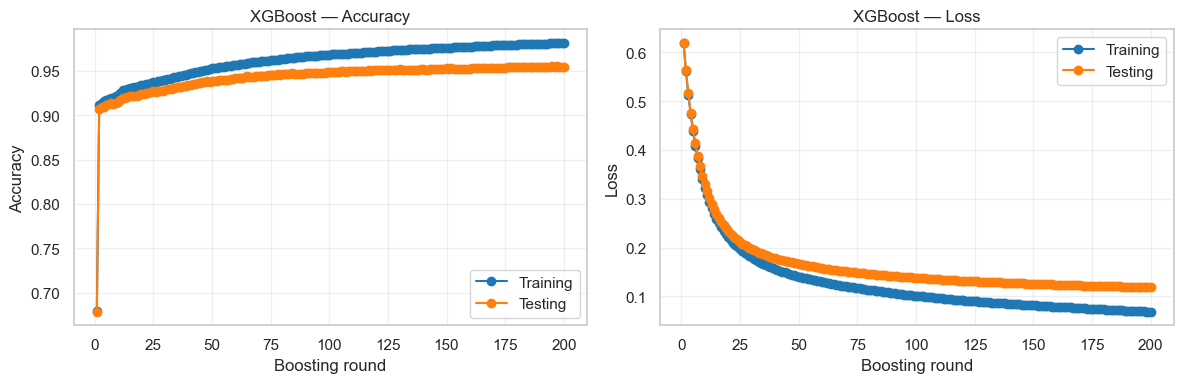

In [21]:
xgb_model = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    eval_metric=['logloss', 'error'], random_state=RANDOM_STATE,
)
xgb_metrics, xgb_preds = evaluate_classifier(
    'XGBoost', xgb_model,
    X_train_tfidf, y_train, X_test_tfidf, y_test,
    fit_params={
        'eval_set': [(X_train_tfidf, y_train), (X_test_tfidf, y_test)],
        'verbose': False,
    },
)
y_pred_xgb = xgb_preds['test']

# Per-iteration train / test curve (free side-product of the fit above).
res = xgb_model.evals_result()
xgb_curve_accs = {
    'train': [1 - e for e in res['validation_0']['error']],
    'test':  [1 - e for e in res['validation_1']['error']],
}
xgb_curve_losses = {
    'train': res['validation_0']['logloss'],
    'test':  res['validation_1']['logloss'],
}
xgb_x = list(range(1, len(xgb_curve_losses['train']) + 1))
plot_acc_loss_curves('XGBoost', xgb_x, xgb_curve_accs, xgb_curve_losses, xlabel='Boosting round')

### 6.6 LightGBM

=== LightGBM ===
Train acc: 0.9943  |  Test acc: 0.9632
Test F1: 0.9593  Precision: 0.9527  Recall: 0.9661  ROC-AUC: 0.9938

              precision    recall  f1-score   support

        Real       0.97      0.96      0.97      6959
        Fake       0.95      0.97      0.96      5666

    accuracy                           0.96     12625
   macro avg       0.96      0.96      0.96     12625
weighted avg       0.96      0.96      0.96     12625



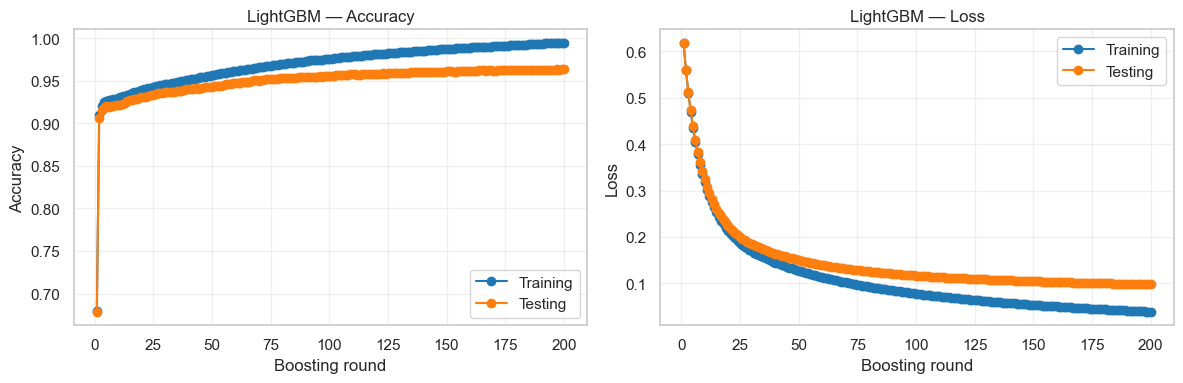

In [22]:
lgbm_model = LGBMClassifier(n_estimators=200, random_state=RANDOM_STATE, verbose=-1)
lgbm_eval = {}
lgbm_metrics, lgbm_preds = evaluate_classifier(
    'LightGBM', lgbm_model,
    X_train_tfidf, y_train, X_test_tfidf, y_test,
    fit_params={
        'eval_set': [(X_train_tfidf, y_train), (X_test_tfidf, y_test)],
        'eval_names': ['train', 'test'],
        'eval_metric': ['binary_logloss', 'binary_error'],
        'callbacks': [lgb.record_evaluation(lgbm_eval)],
    },
)
y_pred_lgbm = lgbm_preds['test']

# Per-iteration train / test curve (free side-product of the fit above).
lgbm_curve_accs = {
    'train': [1 - e for e in lgbm_eval['train']['binary_error']],
    'test':  [1 - e for e in lgbm_eval['test']['binary_error']],
}
lgbm_curve_losses = {
    'train': lgbm_eval['train']['binary_logloss'],
    'test':  lgbm_eval['test']['binary_logloss'],
}
lgbm_x = list(range(1, len(lgbm_curve_losses['train']) + 1))
plot_acc_loss_curves('LightGBM', lgbm_x, lgbm_curve_accs, lgbm_curve_losses, xlabel='Boosting round')

### 6.7 Baseline Comparison

The table below collates all metrics. `TrainAcc` and `TestAcc` come from each split; `F1`, `Precision`, `Recall`, and `ROC-AUC` are reported on the held-out test set.

In [23]:
baseline_results = pd.DataFrame(
    [lr_metrics, rf_metrics, xgb_metrics, lgbm_metrics]
)[
    ['Model', 'TrainAcc', 'TestAcc', 'F1', 'Precision', 'Recall', 'ROC-AUC']
].round(4)
baseline_results

,Model,TrainAcc,TestAcc,F1,Precision,Recall,ROC-AUC
0,Logistic Regression,0.9533,0.9434,0.9370,0.9365,0.9375,0.9857
1,Random Forest,1.0000,0.9380,0.9306,0.9342,0.9271,0.9848
2,XGBoost,0.9816,0.9548,0.9503,0.9381,0.9628,0.9917
3,LightGBM,0.9943,0.9632,0.9593,0.9527,0.9661,0.9938


### 6.8 Train / Test Accuracy Bar Chart

A grouped bar chart of train and test accuracy - same information as the per-iteration curves above, but easier to scan at a glance. A widening gap between the train and test bars indicates overfitting.

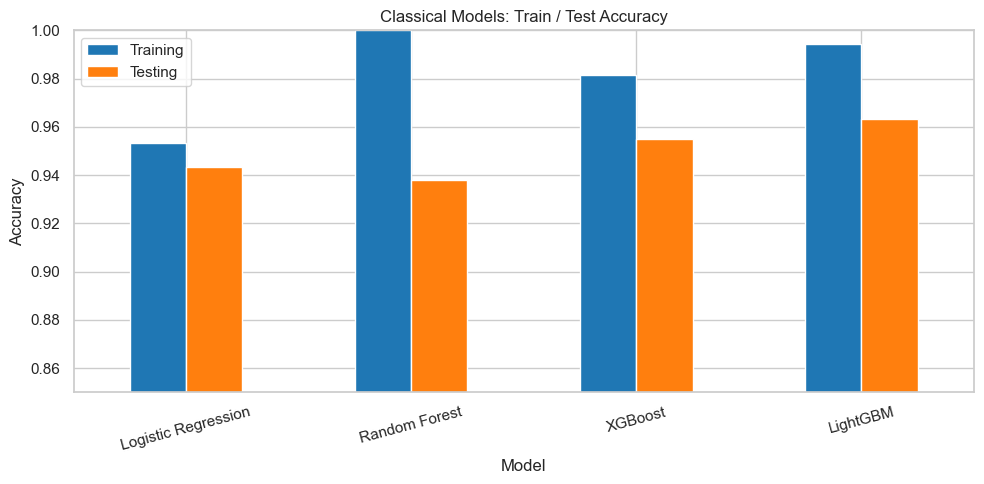

In [24]:
acc_df = baseline_results[['Model', 'TrainAcc', 'TestAcc']].set_index('Model')

fig, ax = plt.subplots(figsize=(10, 5))
acc_df.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e'])
ax.set_ylabel('Accuracy')
ax.set_title('Classical Models: Train / Test Accuracy')
ax.set_ylim(0.85, 1.0)
ax.legend(['Training', 'Testing'])
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 6.9 Learning Curves (Accuracy vs. Training Set Size)

A separate diagnostic from the per-iteration curves: how the test accuracy of each model would change if the training set were smaller. A widening train-test gap at full size indicates overfitting; a still-rising test curve indicates that more data would help.

_Note: this cell refits each model at four training sizes and may take a few minutes on CPU._

   Logistic Regression  size=10,099  train=0.9476  test=0.9266
   Logistic Regression  size=20,198  train=0.9511  test=0.9335
   Logistic Regression  size=35,347  train=0.9526  test=0.9391
   Logistic Regression  size=50,496  train=0.9533  test=0.9434
         Random Forest  size=10,099  train=1.0000  test=0.9171
         Random Forest  size=20,198  train=1.0000  test=0.9294
         Random Forest  size=35,347  train=1.0000  test=0.9320
         Random Forest  size=50,496  train=1.0000  test=0.9372
               XGBoost  size=10,099  train=0.9954  test=0.9459
               XGBoost  size=20,198  train=0.9917  test=0.9494
               XGBoost  size=35,347  train=0.9852  test=0.9529
               XGBoost  size=50,496  train=0.9816  test=0.9545
              LightGBM  size=10,099  train=0.9997  test=0.9460
              LightGBM  size=20,198  train=0.9923  test=0.9530
              LightGBM  size=35,347  train=0.9805  test=0.9547
              LightGBM  size=50,496  train=0.9757  test

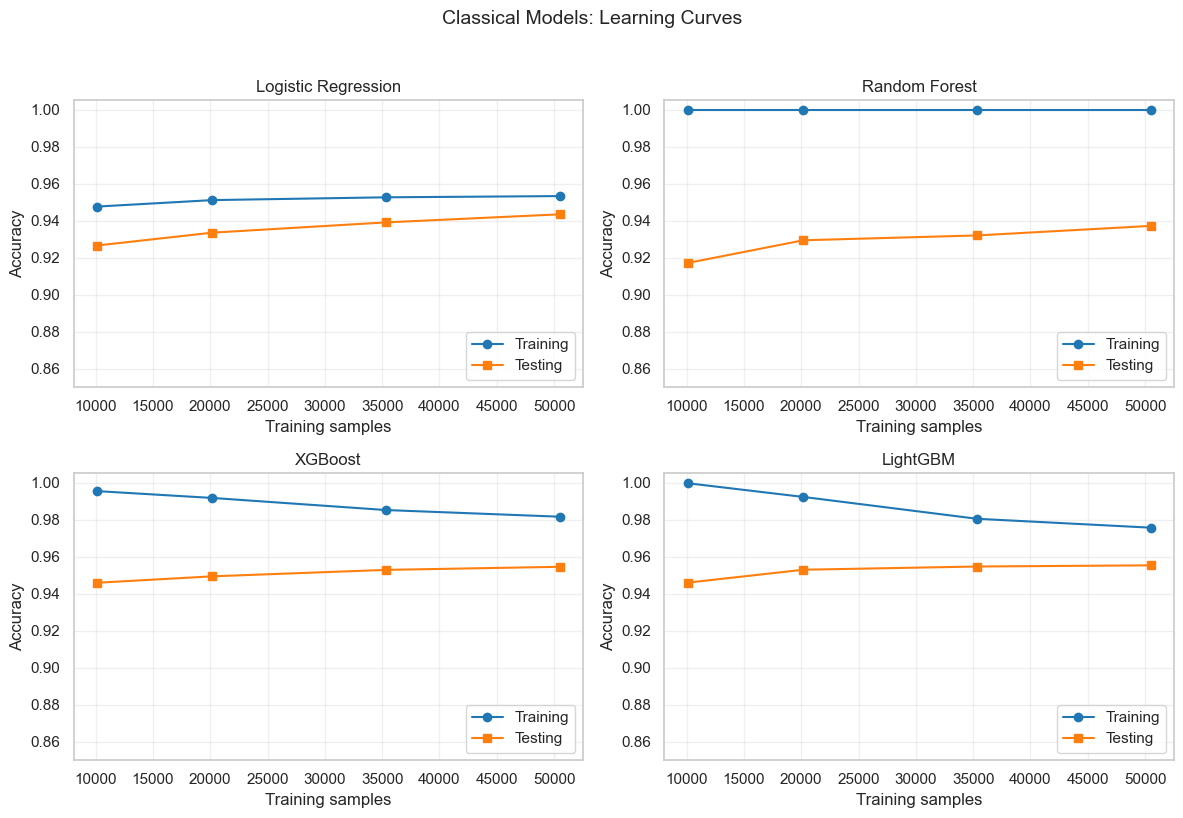

In [25]:
fractions = [0.2, 0.4, 0.7, 1.0]
models_for_curve = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                         eval_metric='logloss', random_state=RANDOM_STATE),
    'LightGBM':            LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
}

rng_lc = np.random.default_rng(RANDOM_STATE)
n_train_total = X_train_tfidf.shape[0]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (name, base_model) in zip(axes.flat, models_for_curve.items()):
    train_accs, test_accs, n_samples = [], [], []
    for frac in fractions:
        k = int(n_train_total * frac)
        idx = rng_lc.choice(n_train_total, size=k, replace=False)
        m = clone(base_model)
        m.fit(X_train_tfidf[idx], y_train[idx])
        train_accs.append(accuracy_score(y_train[idx], m.predict(X_train_tfidf[idx])))
        test_accs.append( accuracy_score(y_test,       m.predict(X_test_tfidf)))
        n_samples.append(k)
        print(f'  {name:>20}  size={k:>6,}  train={train_accs[-1]:.4f}  test={test_accs[-1]:.4f}')
    ax.plot(n_samples, train_accs, '-o', label='Training', color='#1f77b4')
    ax.plot(n_samples, test_accs,  '-s', label='Testing',  color='#ff7f0e')
    ax.set_title(name)
    ax.set_xlabel('Training samples')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0.85, 1.005)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Classical Models: Learning Curves', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 7. LSTM (Long Short-Term Memory)

### 7.1 Rationale

Unlike the bag-of-words TF-IDF representation used in Section 6, a Long Short-Term Memory (LSTM) network consumes a sequence of word tokens **in order**, learning to integrate context across the article. This positions the LSTM between the order-agnostic classical baselines and the contextual transformer in Section 8.

A **bidirectional LSTM** is used so each token sees both its left and right context simultaneously. The architecture is intentionally small (embedding dim 64, hidden dim 64, single bidirectional layer) so training remains feasible on CPU - on a GPU each epoch takes well under a minute.

### 7.2 Vocabulary and Sequence Encoding

The vocabulary is built from the **cleaned training text only** (token-level), capped at the 20 000 most frequent tokens with a minimum frequency of 2. Token id `0` is reserved for padding, id `1` for unknown words. Each article is truncated or padded to a fixed length of 100 tokens.

In [26]:
LSTM_MAX_LEN     = 100
LSTM_MAX_VOCAB   = 20000
LSTM_MIN_FREQ    = 2
LSTM_EMBED_DIM   = 64
LSTM_HIDDEN_DIM  = 64
LSTM_EPOCHS      = 30
LSTM_BATCH_SIZE  = 512 if torch.cuda.is_available() else 64
LSTM_LR          = 1e-3

def build_vocab(texts, max_vocab=LSTM_MAX_VOCAB, min_freq=LSTM_MIN_FREQ):
    counter = Counter()
    for text in texts:
        counter.update(text.split())
    vocab = {'<pad>': 0, '<unk>': 1}
    for word, freq in counter.most_common(max_vocab - 2):
        if freq < min_freq:
            break
        vocab[word] = len(vocab)
    return vocab

def encode(text, vocab, max_len=LSTM_MAX_LEN):
    tokens = text.split()[:max_len]
    ids = [vocab.get(tok, 1) for tok in tokens]
    ids = ids + [0] * (max_len - len(ids))
    return ids

vocab = build_vocab(X_train_text)
LSTM_VOCAB_SIZE = len(vocab)
print(f'Vocabulary size: {LSTM_VOCAB_SIZE:,}')
print(f'LSTM batch size: {LSTM_BATCH_SIZE}  (auto-selected for {"GPU" if torch.cuda.is_available() else "CPU"})')

X_train_seq = np.array([encode(t, vocab) for t in X_train_text], dtype=np.int64)
X_test_seq  = np.array([encode(t, vocab) for t in X_test_text],  dtype=np.int64)
print(f'Train sequences: {X_train_seq.shape}')
print(f'Test  sequences: {X_test_seq.shape}')

Vocabulary size: 20,000
LSTM batch size: 64  (auto-selected for CPU)
Train sequences: (50496, 100)
Test  sequences: (12625, 100)


### 7.3 Model Architecture

A single-layer bidirectional LSTM followed by dropout and a linear classification head:

```
Embedding(vocab_size, 64, padding_idx=0)
    -> BiLSTM(input=64, hidden=64)        # concatenated forward + backward = 128
    -> Dropout(0.3)
    -> Linear(128, 1)
```

Output is a single logit; `BCEWithLogitsLoss` combines a sigmoid and binary cross-entropy in a numerically stable way.

In [27]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=LSTM_EMBED_DIM,
                 hidden_dim=LSTM_HIDDEN_DIM, num_layers=1, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        emb = self.embedding(x)                         # (B, L, E)
        _, (h, _) = self.lstm(emb)                      # h: (num_layers*2, B, H)
        h = h.view(self.lstm.num_layers, 2, x.size(0), self.lstm.hidden_size)
        last = h[-1]                                    # last layer
        pooled = torch.cat([last[0], last[1]], dim=1)   # forward + backward
        return self.fc(self.dropout(pooled)).squeeze(1)

lstm_model   = LSTMClassifier(LSTM_VOCAB_SIZE).to(DEVICE)
lstm_optim   = torch.optim.Adam(lstm_model.parameters(), lr=LSTM_LR)
lstm_loss_fn = nn.BCEWithLogitsLoss()
print(lstm_model)
print(f'Trainable parameters: {sum(p.numel() for p in lstm_model.parameters()):,}')

LSTMClassifier(
  (embedding): Embedding(20000, 64, padding_idx=0)
  (lstm): LSTM(64, 64, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)
Trainable parameters: 1,346,689


### 7.4 Training Loop

Trained with **early stopping** on a held-out **validation split** (10 % of the training
set). After each epoch we measure the validation loss; if it does not improve for
`ES_PATIENCE` consecutive epochs we stop, and the **best-epoch weights are restored** before
evaluation. The test set is *not* used to select the model or the stopping point - it is only
tracked per epoch as a diagnostic. `LSTM_EPOCHS` is therefore an upper bound on the number of
epochs, not a fixed count.

_Note: this is the slowest cell in the notebook on CPU (roughly 5-10 minutes per epoch on the
full ~50k train set). On a GPU each epoch is well under a minute. Reduce `LSTM_EPOCHS` or set a
smaller `LSTM_MAX_LEN` if needed._

In [ ]:
# Full train/test tensors (the final evaluation in 7.6 uses these unchanged).
X_train_seq_t = torch.tensor(X_train_seq, dtype=torch.long)
X_test_seq_t  = torch.tensor(X_test_seq,  dtype=torch.long)
y_test_t_lstm = torch.tensor(y_test, dtype=torch.float32)

# Carve a 10% VALIDATION split out of the TRAIN set for early stopping.
# The test set is never used to select the model (only plotted as a diagnostic).
y_train_full = torch.tensor(y_train, dtype=torch.float32)
_g = torch.Generator().manual_seed(RANDOM_STATE)
_perm  = torch.randperm(X_train_seq_t.shape[0], generator=_g)
_n_val = int(len(_perm) * 0.1)
val_idx, tr_idx = _perm[:_n_val], _perm[_n_val:]

lstm_tr_loader  = DataLoader(TensorDataset(X_train_seq_t[tr_idx],  y_train_full[tr_idx]),
                             batch_size=LSTM_BATCH_SIZE, shuffle=True)
lstm_val_loader = DataLoader(TensorDataset(X_train_seq_t[val_idx], y_train_full[val_idx]),
                             batch_size=256, shuffle=False)
lstm_te_loader  = DataLoader(TensorDataset(X_test_seq_t, y_test_t_lstm),
                             batch_size=256, shuffle=False)

def lstm_epoch_metrics(loader):
    lstm_model.train(False)
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE); yb = yb.to(DEVICE)
            logits = lstm_model(xb)
            total_loss += lstm_loss_fn(logits, yb).item() * yb.size(0)
            preds = (torch.sigmoid(logits) >= 0.5).float()
            correct += (preds == yb).sum().item()
            total   += yb.size(0)
    return total_loss / total, correct / total

ES_PATIENCE = 3          # stop after this many epochs without validation improvement
ES_MIN_DELTA = 1e-4
lstm_history = {k: [] for k in ('train_loss', 'val_loss', 'test_loss',
                                'train_acc', 'val_acc', 'test_acc')}
best_val_loss = float('inf'); best_state = None; no_improve = 0

for epoch in range(1, LSTM_EPOCHS + 1):
    lstm_model.train(True)
    for xb, yb in lstm_tr_loader:
        xb = xb.to(DEVICE); yb = yb.to(DEVICE)
        lstm_optim.zero_grad()
        loss = lstm_loss_fn(lstm_model(xb), yb)
        loss.backward()
        lstm_optim.step()

    tr_loss, tr_acc = lstm_epoch_metrics(lstm_tr_loader)
    va_loss, va_acc = lstm_epoch_metrics(lstm_val_loader)
    te_loss, te_acc = lstm_epoch_metrics(lstm_te_loader)
    for k, v in zip(lstm_history,
                    (tr_loss, va_loss, te_loss, tr_acc, va_acc, te_acc)):
        lstm_history[k].append(v)
    print(f'Epoch {epoch:02d} | train {tr_loss:.4f}/{tr_acc:.4f} '
          f'| val {va_loss:.4f}/{va_acc:.4f} | test {te_loss:.4f}/{te_acc:.4f}')

    if va_loss < best_val_loss - ES_MIN_DELTA:
        best_val_loss = va_loss
        best_state = {k: v.detach().cpu().clone() for k, v in lstm_model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= ES_PATIENCE:
            print(f'Early stopping at epoch {epoch} '
                  f'(no val improvement for {ES_PATIENCE} epochs).')
            break

if best_state is not None:
    lstm_model.load_state_dict(best_state)
    print(f'Restored best LSTM weights (val loss {best_val_loss:.4f}).')

### 7.5 Training Curves

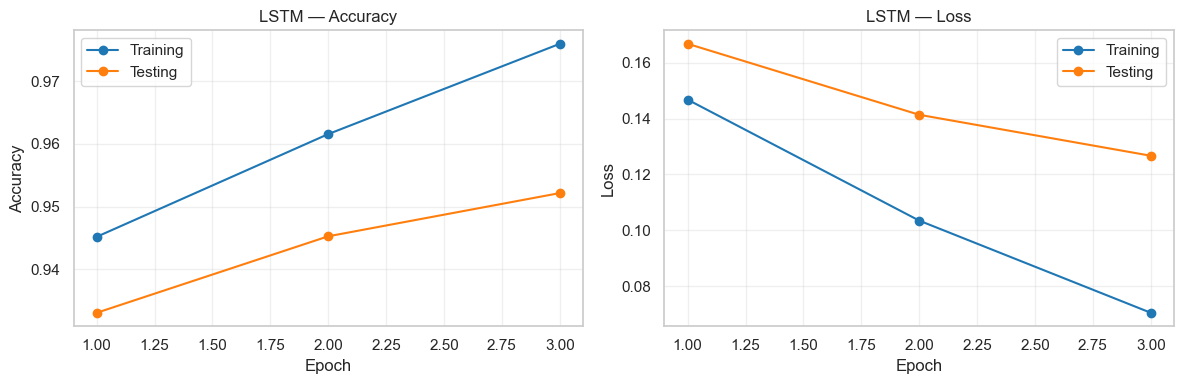

In [29]:
lstm_x = list(range(1, len(lstm_history['train_acc']) + 1))
plot_acc_loss_curves(
    'LSTM', lstm_x,
    {'train': lstm_history['train_acc'],  'test': lstm_history['test_acc']},
    {'train': lstm_history['train_loss'], 'test': lstm_history['test_loss']},
    xlabel='Epoch',
)

### 7.6 Test Evaluation

In [30]:
def lstm_predict(X_t, batch_size=256):
    lstm_model.train(False)
    all_probs = []
    with torch.no_grad():
        for i in range(0, X_t.shape[0], batch_size):
            chunk = X_t[i:i + batch_size].to(DEVICE)
            logits = lstm_model(chunk)
            all_probs.append(torch.sigmoid(logits).cpu().numpy())
    probs = np.concatenate(all_probs)
    return probs, (probs >= 0.5).astype(int)

lstm_train_probs, y_pred_lstm_train = lstm_predict(X_train_seq_t)
lstm_test_probs,  y_pred_lstm       = lstm_predict(X_test_seq_t)

lstm_metrics = {
    'Model':     'LSTM',
    'TrainAcc':  accuracy_score(y_train, y_pred_lstm_train),
    'TestAcc':   accuracy_score(y_test,  y_pred_lstm),
    'F1':        f1_score(y_test,         y_pred_lstm),
    'Precision': precision_score(y_test,  y_pred_lstm),
    'Recall':    recall_score(y_test,     y_pred_lstm),
    'ROC-AUC':   roc_auc_score(y_test,    lstm_test_probs),
}

print('=== LSTM ===')
print(f'Train acc: {lstm_metrics["TrainAcc"]:.4f}  |  Test acc: {lstm_metrics["TestAcc"]:.4f}')
print(f'Test F1: {lstm_metrics["F1"]:.4f}  Precision: {lstm_metrics["Precision"]:.4f}  Recall: {lstm_metrics["Recall"]:.4f}  ROC-AUC: {lstm_metrics["ROC-AUC"]:.4f}')
print()
print(classification_report(y_test, y_pred_lstm, target_names=['Real', 'Fake']))

=== LSTM ===
Train acc: 0.9760  |  Test acc: 0.9522
Test F1: 0.9468  Precision: 0.9447  Recall: 0.9490  ROC-AUC: 0.9895

              precision    recall  f1-score   support

        Real       0.96      0.95      0.96      6959
        Fake       0.94      0.95      0.95      5666

    accuracy                           0.95     12625
   macro avg       0.95      0.95      0.95     12625
weighted avg       0.95      0.95      0.95     12625



## 8. Transformer Approach: PyTorch + DistilBERT

### 8.1 Rationale

Full BERT fine-tuning is expensive on CPU (multiple hours per epoch on this dataset) and still costly on consumer-grade GPUs. To keep the notebook portable across hardware, this section uses **DistilBERT** - a distilled variant of BERT with ~40% fewer parameters and ~60% faster inference - and treats it as a **frozen feature extractor**:

1. Each article is tokenized and passed through DistilBERT once.
2. The hidden state of the `[CLS]` token is taken as a 768-dimensional sentence embedding.
3. A small PyTorch MLP head is trained on top of these embeddings.

Unlike the LSTM in Section 7, the DistilBERT encoder is **not trained** here - it provides pre-learned contextual representations that the head then maps to the binary label. This is the standard frozen-encoder transfer-learning pattern. It is also hardware-agnostic: on a GPU the embedding pass and head training are both several times faster, but the workload remains feasible on CPU because the encoder is never updated.

In [31]:
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN    = 128

# Batch size and FP16 default to GPU-friendly settings when CUDA is available.
if DEVICE.type == 'cuda':
    BATCH_SIZE = 256
    USE_FP16   = True
else:
    BATCH_SIZE = 32
    USE_FP16   = False

# Optional subsampling for faster execution.
# Set to None to use the full split; or e.g. 10000 to use a stratified subset.
SAMPLE_SIZE = None

print(f'BERT batch size: {BATCH_SIZE}  |  FP16: {USE_FP16}')

BERT batch size: 32  |  FP16: False


### 8.2 Tokenizer and Encoder Setup

The encoder is loaded once, switched to inference mode, and all of its parameters are frozen - only the small classifier head defined below will be trained.

In [32]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
encoder   = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
encoder.train(False)  # switch to inference mode
for p in encoder.parameters():
    p.requires_grad = False

total_params = sum(p.numel() for p in encoder.parameters())
print(f'Encoder parameters: {total_params:,}')

Encoder parameters: 66,362,880


### 8.3 Embedding Extraction

Embedding extraction is a forward pass under `torch.no_grad()`. For each article, the `[CLS]` token's last hidden state is taken as a 768-dimensional summary vector.

In [33]:
def embed_texts(texts, batch_size=BATCH_SIZE):
    embeddings = []
    n = len(texts)
    for start in range(0, n, batch_size):
        batch = list(texts[start:start + batch_size])
        enc = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=MAX_LEN,
            return_tensors='pt',
        ).to(DEVICE)
        with torch.no_grad():
            if USE_FP16:
                with torch.autocast(device_type=DEVICE.type, dtype=torch.float16):
                    outputs = encoder(**enc)
            else:
                outputs = encoder(**enc)
        # Cast back to float32 for stable storage on host RAM.
        cls_vec = outputs.last_hidden_state[:, 0, :].float()
        embeddings.append(cls_vec.cpu())
        if (start // batch_size) % 50 == 0:
            print(f'  ... {min(start + batch_size, n):,}/{n:,}')
    return torch.cat(embeddings, dim=0)

In [34]:
if SAMPLE_SIZE is not None:
    rng = np.random.default_rng(RANDOM_STATE)
    n_test_target = max(1, SAMPLE_SIZE * 20 // 80)
    tr_sel = rng.choice(len(X_train_raw), size=min(SAMPLE_SIZE,    len(X_train_raw)), replace=False)
    te_sel = rng.choice(len(X_test_raw),  size=min(n_test_target,  len(X_test_raw)),  replace=False)
    train_texts = X_train_raw[tr_sel];  y_train_dl = y_train[tr_sel]
    test_texts  = X_test_raw[te_sel];   y_test_dl  = y_test[te_sel]
else:
    train_texts, y_train_dl = X_train_raw, y_train
    test_texts,  y_test_dl  = X_test_raw,  y_test

print(f'Embedding {len(train_texts):,} training articles...')
X_train_emb = embed_texts(train_texts)
print(f'Embedding {len(test_texts):,} test articles...')
X_test_emb  = embed_texts(test_texts)

print(f'Train embeddings: {tuple(X_train_emb.shape)}')
print(f'Test  embeddings: {tuple(X_test_emb.shape)}')

Embedding 50,496 training articles...
  ... 32/50,496
  ... 1,632/50,496
  ... 3,232/50,496
  ... 4,832/50,496
  ... 6,432/50,496
  ... 8,032/50,496
  ... 9,632/50,496
  ... 11,232/50,496
  ... 12,832/50,496
  ... 14,432/50,496
  ... 16,032/50,496
  ... 17,632/50,496
  ... 19,232/50,496
  ... 20,832/50,496
  ... 22,432/50,496
  ... 24,032/50,496
  ... 25,632/50,496
  ... 27,232/50,496
  ... 28,832/50,496
  ... 30,432/50,496
  ... 32,032/50,496
  ... 33,632/50,496
  ... 35,232/50,496
  ... 36,832/50,496
  ... 38,432/50,496
  ... 40,032/50,496
  ... 41,632/50,496
  ... 43,232/50,496
  ... 44,832/50,496
  ... 46,432/50,496
  ... 48,032/50,496
  ... 49,632/50,496
Embedding 12,625 test articles...
  ... 32/12,625
  ... 1,632/12,625
  ... 3,232/12,625
  ... 4,832/12,625
  ... 6,432/12,625
  ... 8,032/12,625
  ... 9,632/12,625
  ... 11,232/12,625
Train embeddings: (50496, 768)
Test  embeddings: (12625, 768)


### 8.4 Classifier Head

A two-layer MLP is trained on the frozen embeddings:

```
Linear(768 -> 128) -> ReLU -> Dropout(0.2) -> Linear(128 -> 1)
```

The output is a single logit; `BCEWithLogitsLoss` combines a sigmoid and binary cross-entropy in a numerically stable way.

In [35]:
class ClassifierHead(nn.Module):
    def __init__(self, in_dim: int = 768, hidden: int = 128, dropout: float = 0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x)

head = ClassifierHead(in_dim=X_train_emb.shape[1]).to(DEVICE)
optimizer = torch.optim.Adam(head.parameters(), lr=1e-3)
loss_fn   = nn.BCEWithLogitsLoss()
print(head)

ClassifierHead(
  (net): Sequential(
    (0): Linear(in_features=768, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)


### 8.5 Training Loop

The MLP head is trained on the frozen embeddings with **early stopping** on a held-out
**validation split** (10 % of the training embeddings). After each epoch we measure the
validation loss; if it does not improve for `ES_PATIENCE` consecutive epochs we stop and
**restore the best-epoch weights**. The test set is plotted alongside training purely as a
per-epoch diagnostic; it is **never used to update the model or choose the stopping epoch**.
`EPOCHS` is an upper bound, not a fixed count.

In [ ]:
y_train_t = torch.tensor(y_train_dl, dtype=torch.float32)
y_test_t  = torch.tensor(y_test_dl,  dtype=torch.float32)

# Carve a 10% VALIDATION split out of the TRAIN embeddings for early stopping.
_gb = torch.Generator().manual_seed(RANDOM_STATE)
_permb  = torch.randperm(X_train_emb.shape[0], generator=_gb)
_n_valb = int(len(_permb) * 0.1)
val_idx_b, tr_idx_b = _permb[:_n_valb], _permb[_n_valb:]

tr_loader   = DataLoader(TensorDataset(X_train_emb[tr_idx_b],  y_train_t[tr_idx_b]),
                         batch_size=64,  shuffle=True)
val_loader  = DataLoader(TensorDataset(X_train_emb[val_idx_b], y_train_t[val_idx_b]),
                         batch_size=256, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_emb,  y_test_t),  batch_size=256, shuffle=False)

def epoch_metrics(loader):
    head.train(False)
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE); yb = yb.to(DEVICE)
            logits = head(xb).squeeze(1)
            total_loss += loss_fn(logits, yb).item() * xb.size(0)
            preds = (torch.sigmoid(logits) >= 0.5).float()
            correct += (preds == yb).sum().item()
            total += xb.size(0)
    return total_loss / total, correct / total

EPOCHS = 30              # upper bound; early stopping usually halts sooner
ES_PATIENCE = 3          # stop after this many epochs without validation improvement
ES_MIN_DELTA = 1e-4
history = {k: [] for k in ('train_loss', 'val_loss', 'test_loss',
                           'train_acc', 'val_acc', 'test_acc')}
best_val_loss = float('inf'); best_state = None; no_improve = 0

for epoch in range(1, EPOCHS + 1):
    head.train(True)
    for xb, yb in tr_loader:
        xb = xb.to(DEVICE); yb = yb.to(DEVICE)
        optimizer.zero_grad()
        loss = loss_fn(head(xb).squeeze(1), yb)
        loss.backward()
        optimizer.step()

    tr_loss, tr_acc = epoch_metrics(tr_loader)
    va_loss, va_acc = epoch_metrics(val_loader)
    te_loss, te_acc = epoch_metrics(test_loader)
    for k, v in zip(history,
                    (tr_loss, va_loss, te_loss, tr_acc, va_acc, te_acc)):
        history[k].append(v)
    print(f'Epoch {epoch:02d} | train {tr_loss:.4f}/{tr_acc:.4f} '
          f'| val {va_loss:.4f}/{va_acc:.4f} | test {te_loss:.4f}/{te_acc:.4f}')

    if va_loss < best_val_loss - ES_MIN_DELTA:
        best_val_loss = va_loss
        best_state = {k: v.detach().cpu().clone() for k, v in head.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= ES_PATIENCE:
            print(f'Early stopping at epoch {epoch} '
                  f'(no val improvement for {ES_PATIENCE} epochs).')
            break

if best_state is not None:
    head.load_state_dict(best_state)
    print(f'Restored best head weights (val loss {best_val_loss:.4f}).')

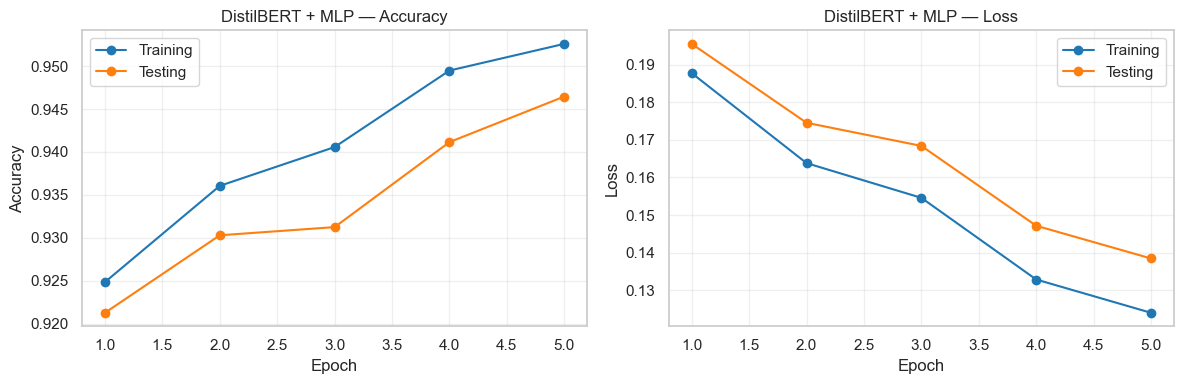

In [37]:
x = list(range(1, len(history['train_acc']) + 1))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(x, history['train_acc'], '-o', label='Training', color='#1f77b4')
axes[0].plot(x, history['test_acc'],  '-o', label='Testing',  color='#ff7f0e')
axes[0].set_title('DistilBERT + MLP \u2014 Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(x, history['train_loss'], '-o', label='Training', color='#1f77b4')
axes[1].plot(x, history['test_loss'],  '-o', label='Testing',  color='#ff7f0e')
axes[1].set_title('DistilBERT + MLP \u2014 Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 8.6 Test-Set Evaluation

In [38]:
def bert_predict(emb, batch_size=256):
    """Predict in batches so we don't shove the whole tensor onto GPU at once."""
    head.train(False)
    all_probs = []
    with torch.no_grad():
        for i in range(0, emb.shape[0], batch_size):
            chunk = emb[i:i + batch_size].to(DEVICE)
            logits = head(chunk).squeeze(1)
            all_probs.append(torch.sigmoid(logits).cpu().numpy())
    probs = np.concatenate(all_probs)
    return probs, (probs >= 0.5).astype(int)

train_probs, y_pred_bert_train = bert_predict(X_train_emb)
test_probs,  y_pred_bert       = bert_predict(X_test_emb)

bert_metrics = {
    'Model':     'DistilBERT + MLP',
    'TrainAcc':  accuracy_score(y_train_dl, y_pred_bert_train),
    'TestAcc':   accuracy_score(y_test_dl,  y_pred_bert),
    'F1':        f1_score(y_test_dl,        y_pred_bert),
    'Precision': precision_score(y_test_dl, y_pred_bert),
    'Recall':    recall_score(y_test_dl,    y_pred_bert),
    'ROC-AUC':   roc_auc_score(y_test_dl,   test_probs),
}

print('=== DistilBERT + MLP ===')
print(f'Train acc: {bert_metrics["TrainAcc"]:.4f}  |  Test acc: {bert_metrics["TestAcc"]:.4f}')
print(f'Test F1: {bert_metrics["F1"]:.4f}  Precision: {bert_metrics["Precision"]:.4f}  Recall: {bert_metrics["Recall"]:.4f}  ROC-AUC: {bert_metrics["ROC-AUC"]:.4f}')
print()
print(classification_report(y_test_dl, y_pred_bert, target_names=['Real', 'Fake']))

# Legacy aliases used by downstream cells.
bert_f1  = bert_metrics['F1']
bert_acc = bert_metrics['TestAcc']

=== DistilBERT + MLP ===
Train acc: 0.9526  |  Test acc: 0.9465
Test F1: 0.9405  Precision: 0.9382  Recall: 0.9428  ROC-AUC: 0.9881

              precision    recall  f1-score   support

        Real       0.95      0.95      0.95      6959
        Fake       0.94      0.94      0.94      5666

    accuracy                           0.95     12625
   macro avg       0.95      0.95      0.95     12625
weighted avg       0.95      0.95      0.95     12625



## 9. Results & Discussion

### 9.1 Combined Comparison

In [39]:
all_results = pd.concat([
    baseline_results,
    pd.DataFrame([lstm_metrics, bert_metrics])[
        ['Model', 'TrainAcc', 'TestAcc', 'F1', 'Precision', 'Recall', 'ROC-AUC']
    ],
], ignore_index=True).round(4)
all_results.sort_values('F1', ascending=False, ignore_index=True)

,Model,TrainAcc,TestAcc,F1,Precision,Recall,ROC-AUC
0,LightGBM,0.9943,0.9632,0.9593,0.9527,0.9661,0.9938
1,XGBoost,0.9816,0.9548,0.9503,0.9381,0.9628,0.9917
2,LSTM,0.9760,0.9522,0.9468,0.9447,0.9490,0.9895
3,DistilBERT + MLP,0.9526,0.9465,0.9405,0.9382,0.9428,0.9881
4,Logistic Regression,0.9533,0.9434,0.9370,0.9365,0.9375,0.9857
5,Random Forest,1.0000,0.9380,0.9306,0.9342,0.9271,0.9848


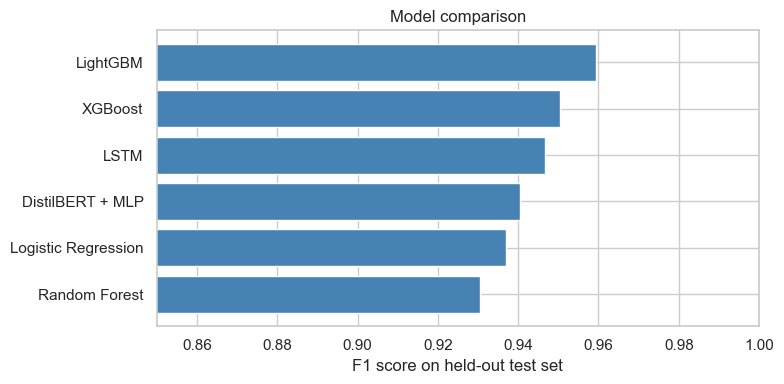

In [40]:
plt.figure(figsize=(8, 4))
sorted_res = all_results.sort_values('F1', ascending=True)
plt.barh(sorted_res['Model'], sorted_res['F1'], color='steelblue')
plt.xlabel('F1 score on held-out test set')
plt.title('Model comparison')
plt.xlim(0.85, 1.0)
plt.tight_layout()
plt.show()

### 9.2 Confusion Matrices

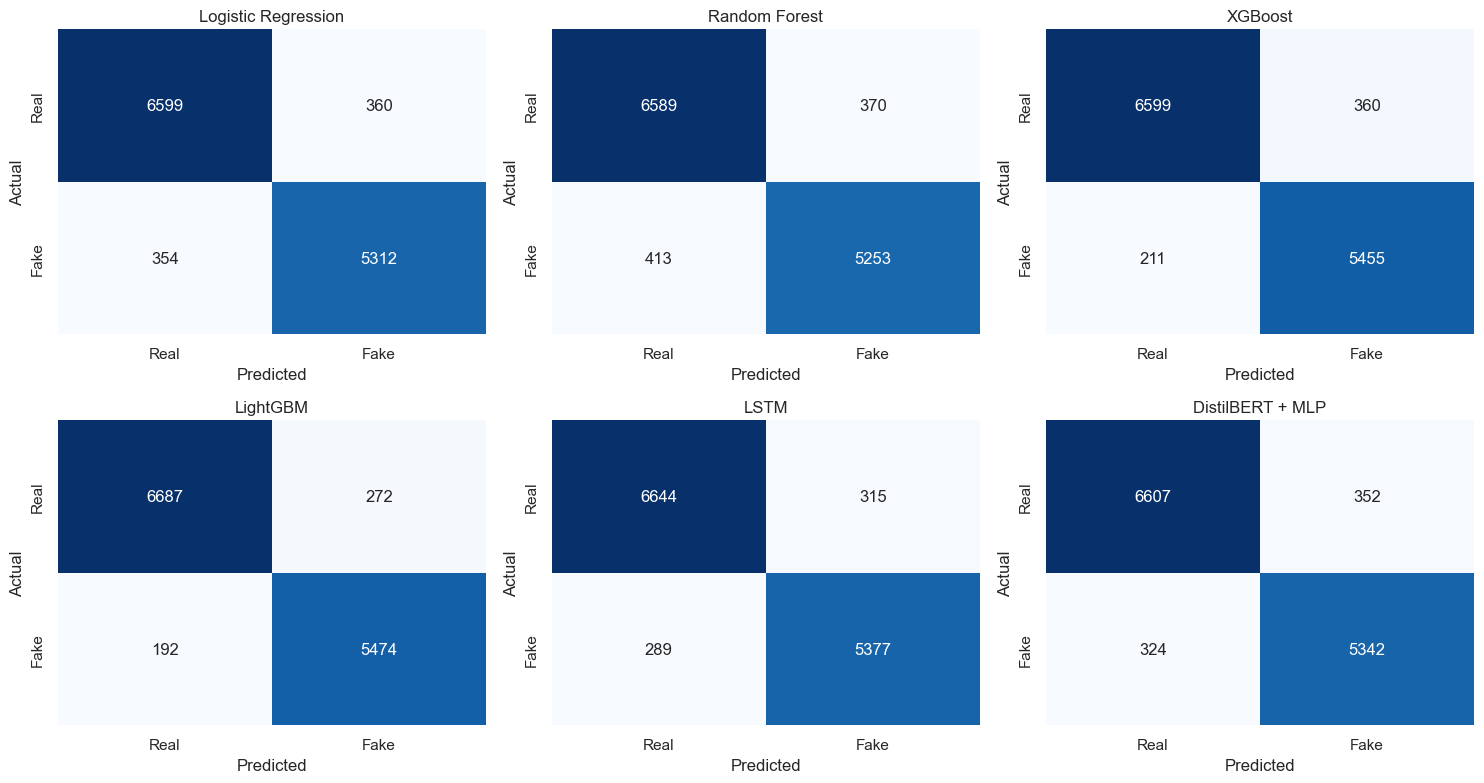

In [41]:
preds_for_cm = {
    'Logistic Regression': (y_test,    y_pred_lr),
    'Random Forest':       (y_test,    y_pred_rf),
    'XGBoost':             (y_test,    y_pred_xgb),
    'LightGBM':            (y_test,    y_pred_lgbm),
    'LSTM':                (y_test,    y_pred_lstm),
    'DistilBERT + MLP':    (y_test_dl, y_pred_bert),
}
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (name, (yt, yp)) in zip(axes.flat, preds_for_cm.items()):
    sns.heatmap(
        confusion_matrix(yt, yp), annot=True, fmt='d', cmap='Blues',
        xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'],
        ax=ax, cbar=False,
    )
    ax.set_title(name)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

### 9.3 Error Analysis

A small qualitative inspection of misclassified articles helps motivate future work.

In [42]:
mis_idx = np.where(y_pred_bert != y_test_dl)[0][:5]
for i in mis_idx:
    print(f'True: {y_test_dl[i]} | Predicted: {y_pred_bert[i]}')
    print(test_texts[i][:300].replace(chr(10), ' '))
    print('-' * 80)

True: 1 | Predicted: 0
 Why The Death Of Justice Scalia Makes The Supreme Court A Huge 2016 Election Issue The death of Justice Antonin Scalia at the age of 79, while sad for his family, represents an opportunity to change the Supreme Court and America with a single nomination.The Supreme Court has leaned conservative for
--------------------------------------------------------------------------------
True: 0 | Predicted: 1
Hillary: Russian Hacking Had To Be ’Guided by Americans,’ Might Have Been Trump - Breitbart Wednesday in Ranchos Palos Verdes, CA at the annual Code Conference, former Democratic presidential candidate Hillary Clinton said the barrage of “fake news” and hacked emails released during the 2016 preside
--------------------------------------------------------------------------------
True: 1 | Predicted: 0
 Half The World’s Salmon Supply Threatened As Trump’s EPA Withdraws Alaskan Mining Restrictions The U.S. Environmental Protection Agency gave the go-ahead on Friday fo

## 10. Explainability (XAI)

Sections 6-9 established *how accurately* each model separates real from fake articles. This section asks the complementary question that motivates the thesis: **why** does a model label a given article as fake, and do the different model *architectures* rely on the same evidence? Accuracy alone is insufficient for a system that may inform moderation or fact-checking decisions - such a system must also be *interpretable* and *auditable*.

To keep the analysis clean and reproducible we standardise on a **single** explanation method - **SHAP** - and apply it uniformly to **every** model (Logistic Regression, Random Forest, XGBoost, LightGBM, the LSTM, and DistilBERT). Holding the explanation method fixed turns the comparison into a *controlled* experiment: any difference we observe is attributable to the **architecture**, not to a change of explainer. All explanations reuse the **already-trained** models from Sections 6-8 (no retraining).

### 10.1 Background: Explainable AI for Misinformation

**Why explainability.** Modern fake-news classifiers - gradient-boosted ensembles and transformers alike - are effectively *black boxes*: they output a probability without exposing the reasoning behind it. In a misinformation setting this is a real limitation. A moderator needs to know *which words or claims* triggered a 'fake' verdict in order to trust, contest, or act on it, and a researcher needs it to detect when a model has latched onto a spurious shortcut (e.g. a publication's stylistic quirks) rather than genuine deceptive content. Explainable AI (XAI) is the body of techniques that makes these decisions inspectable.

**Two axes of explanation.** XAI methods are commonly organised along two axes. *Intrinsic vs. post-hoc:* intrinsic models are transparent by construction (e.g. a shallow decision tree), whereas post-hoc methods explain an already-trained black box from the outside; because our models were optimised purely for accuracy we use **post-hoc** methods. *Local vs. global:* a *global* explanation describes the model's behaviour over the whole dataset (which features matter on average), while a *local* explanation justifies a single prediction. We report both.

**Why SHAP - and why a single method.** Several post-hoc methods are widely used for text classifiers, and we deliberately considered the main alternatives before settling on one:

- **LIME** (Ribeiro et al., 2016) perturbs the input and fits a local linear surrogate. It is intuitive and model-agnostic, but its explanations are *local-only* and can vary run-to-run because the perturbation sampling is stochastic.
- **Attention visualisation** is cheap for transformers (a single forward pass) but the community treats raw attention weights as *suggestive, not faithful* - they do not reliably reflect the output.
- **Integrated Gradients** (Sundararajan et al., 2017) is a faithful gradient-based attribution, but it applies only to differentiable models - it cannot explain the tree and linear baselines, so it could never be the *one* method used across the whole study.

**SHAP** (SHapley Additive exPlanations; Lundberg & Lee, 2017) assigns each feature a contribution using Shapley values from cooperative game theory. It is the natural choice for a single unified method because it is the only one that (a) covers *every* model family in this study - exact `TreeExplainer` for the gradient-boosted ensembles, `LinearExplainer` for Logistic Regression, and a model-agnostic Partition explainer (text masker) for the recurrent and transformer networks - and (b) provides *both* global and local views, with additivity and consistency guarantees. Surveys of XAI for misinformation report a clear preference for SHAP on grounds of stability and theoretical grounding.

**Faithfulness vs. plausibility.** A recurring theme in recent surveys is that an explanation can look convincing to a human (*plausible*) while not actually reflecting the model's computation (*faithful*). Robustly *measuring* faithfulness (e.g. comprehensiveness / sufficiency) is an active research area and is left as future work (Section 11); here we report SHAP explanations qualitatively and cross-check them across the classical / recurrent / transformer divide, which is itself a practical consistency test.

### 10.1.1 XAI Dependencies

SHAP powers Section 10. It is imported lazily (and installed on demand) so that the rest of the notebook runs even if it is absent.

In [ ]:
# Lazy install/import so Sections 1-9 do not depend on SHAP.
import importlib, subprocess, sys

def _ensure(pkg, import_name=None):
    name = import_name or pkg
    try:
        return importlib.import_module(name)
    except ImportError:
        print(f'Installing {pkg} ...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
        return importlib.import_module(name)

shap = _ensure('shap')
print('shap', shap.__version__, 'ready')

### 10.2 Global Feature Importance - SHAP on the Classical Models

For the four TF-IDF classical models we use SHAP's **exact** explainers (still SHAP, just the fast specialisation per model type): `LinearExplainer` for Logistic Regression and `TreeExplainer` for the Random Forest, XGBoost, and LightGBM ensembles. Because dense SHAP plots are heavy, we explain a random sample of the test set. Each TF-IDF column maps back to a stemmed token via `tfidf.get_feature_names_out()`. A **positive** SHAP value pushes the prediction toward class **Fake** (label 1); negative pushes toward **Real** (label 0).

In [ ]:
# Token vocabulary behind the TF-IDF columns
feature_names = np.array(tfidf.get_feature_names_out())

# Random sample of the test set for a tractable global view
rng = np.random.default_rng(RANDOM_STATE)
n_shap = min(2000, X_test_tfidf.shape[0])
shap_idx = rng.choice(X_test_tfidf.shape[0], size=n_shap, replace=False)
X_shap       = X_test_tfidf[shap_idx]
X_shap_dense = X_shap.toarray()

classical_models = {
    'Logistic Regression': lr_model,
    'Random Forest':       rf_model,
    'XGBoost':             xgb_model,
    'LightGBM':            lgbm_model,
}

def classical_shap_values(name, model):
    """Exact class-'Fake' SHAP values on the global sample. Linear model uses
    LinearExplainer; tree ensembles use TreeExplainer."""
    if name == 'Logistic Regression':
        sv = shap.LinearExplainer(model, X_shap).shap_values(X_shap)
    else:
        sv = shap.TreeExplainer(model).shap_values(X_shap_dense)
    # Normalise across shap versions: list[2] (old) or (n, feat, classes) (new) -> class 1.
    if isinstance(sv, list):
        sv = sv[1]
    sv = np.asarray(sv)
    if sv.ndim == 3:
        sv = sv[:, :, 1]
    return sv

classical_shap = {name: classical_shap_values(name, m)
                  for name, m in classical_models.items()}
for name, sv in classical_shap.items():
    print(f'{name:20s} SHAP values: {np.asarray(sv).shape}')

In [ ]:
# Global importance per classical model: beeswarm (signed) + mean|SHAP| bar.
for name, sv in classical_shap.items():
    print(f'===== {name} =====')
    shap.summary_plot(sv, X_shap_dense, feature_names=feature_names,
                      max_display=20, show=True)
    shap.summary_plot(sv, X_shap_dense, feature_names=feature_names,
                      plot_type='bar', max_display=20, show=True)

**Do the classical models agree?** A useful sanity check is whether models with very different inductive biases (a linear model, a bagged forest, and two boosted ensembles) rely on the same vocabulary. We rank each model's tokens by mean absolute SHAP and look at the overlap of their top-15 lists.

In [ ]:
def top_tokens(sv, k=15):
    order = np.argsort(np.abs(sv).mean(axis=0))[::-1][:k]
    return list(feature_names[order])

top_by_model = {name: top_tokens(sv) for name, sv in classical_shap.items()}
for name, toks in top_by_model.items():
    print(f'{name:20s}: {toks}')

common = set.intersection(*(set(t) for t in top_by_model.values()))
print(f'\nShared by ALL four classical models (top-15): {sorted(common)}')

### 10.3 Local Explanations - SHAP on the Same Articles, Across All Six Models

This is the heart of the controlled comparison. We pick three representative test articles - a confidently-correct **Fake**, a confidently-correct **Real**, and the model's *most confident mistake* (echoing the error analysis in 9.3) - and explain each prediction with **the same SHAP method on every model**.

Every model is wrapped as a `raw text -> P(class)` function and handed to one `shap.Explainer` with a word-level **Text masker** (the model-agnostic Partition explainer). Because the masker tokenises each article on the *same* word regex regardless of model, the resulting token attributions are **directly comparable across architectures** - no stem-prefix approximation is needed.

In [ ]:
# Select example articles from the LightGBM predictions on the held-out test set
proba_fake = lgbm_model.predict_proba(X_test_tfidf)[:, 1]
pred = (proba_fake >= 0.5).astype(int)
y_te = np.asarray(y_test)

tp  = np.where((pred == 1) & (y_te == 1))[0]   # predicted Fake, truly Fake
tn  = np.where((pred == 0) & (y_te == 0))[0]   # predicted Real, truly Real
err = np.where(pred != y_te)[0]                # misclassified

examples = {
    'Confident Fake':  int(tp[np.argmax(proba_fake[tp])]),
    'Confident Real':  int(tn[np.argmin(proba_fake[tn])]),
    'Confident Error': int(err[np.argmax(np.abs(proba_fake[err] - 0.5))]),
}
for name, i in examples.items():
    print(f'{name:16s} idx={i:6d}  P(Fake)={proba_fake[i]:.3f}  '
          f'true={"Fake" if y_te[i]==1 else "Real"}')

In [ ]:
# --- One raw-text -> P([Real, Fake]) wrapper per model, reproducing its training path ---
def make_classical_proba_raw(model):
    """raw text -> cleaning() (5.3) -> tfidf.transform -> predict_proba."""
    def f(texts):
        cleaned = [cleaning(str(t)) for t in texts]
        return model.predict_proba(tfidf.transform(cleaned))
    return f

def lstm_predict_proba_raw(texts):
    """raw text -> cleaning -> encode(vocab) -> LSTM -> [P(Real), P(Fake)]."""
    cleaned = [cleaning(str(t)) for t in texts]
    seqs = np.array([encode(t, vocab) for t in cleaned], dtype=np.int64)
    p_fake, _ = lstm_predict(torch.tensor(seqs, dtype=torch.long))
    p_fake = np.asarray(p_fake).reshape(-1)
    return np.column_stack([1.0 - p_fake, p_fake])

def bert_predict_proba_raw(texts):
    """raw text -> DistilBERT [CLS] -> trained head -> [P(Real), P(Fake)]. Quiet
    re-implementation of embed_texts + bert_predict (no progress prints, since SHAP
    calls this many times)."""
    texts = [str(t) for t in texts]
    encoder.train(False); head.train(False)
    probs = []
    with torch.no_grad():
        for s in range(0, len(texts), BATCH_SIZE):
            enc = tokenizer(texts[s:s + BATCH_SIZE], padding=True, truncation=True,
                            max_length=MAX_LEN, return_tensors='pt').to(DEVICE)
            cls = encoder(**enc).last_hidden_state[:, 0, :].float()
            logit = head(cls).squeeze(-1)
            probs.append(torch.sigmoid(logit).cpu().numpy())
    p_fake = np.concatenate(probs).reshape(-1)
    return np.column_stack([1.0 - p_fake, p_fake])

proba_raw_by_model = {
    'Logistic Regression': make_classical_proba_raw(lr_model),
    'Random Forest':       make_classical_proba_raw(rf_model),
    'XGBoost':             make_classical_proba_raw(xgb_model),
    'LightGBM':            make_classical_proba_raw(lgbm_model),
    'LSTM':                lstm_predict_proba_raw,
    'DistilBERT + MLP':    bert_predict_proba_raw,
}

# Sanity check: every wrapper must reproduce P(Fake) on a known article.
_i = examples['Confident Fake']
print(f"Reference LightGBM P(Fake) for 'Confident Fake' = {proba_fake[_i]:.3f}")
for name, fn in proba_raw_by_model.items():
    print(f'  {name:20s} P(Fake) = {fn([X_test_raw[_i]])[0, 1]:.3f}')

In [ ]:
# --- One SHAP explainer (Text masker = Partition) applied to every model ---
# Truncate the example articles to keep the Partition search tractable and readable.
def truncate_words(t, n=120):
    return ' '.join(str(t).split()[:n])

example_articles = [truncate_words(X_test_raw[i]) for i in examples.values()]
example_labels   = list(examples.keys())
masker = shap.maskers.Text(r"\W+")

local_sv = {}
for name, fn in proba_raw_by_model.items():
    explainer = shap.Explainer(fn, masker, output_names=['Real', 'Fake'])
    sv = explainer(example_articles, max_evals=500)
    local_sv[name] = sv
    for j, lab in enumerate(example_labels):
        print(f'----- {name}  |  {lab} -----')
        shap.plots.text(sv[j, :, 1])   # attribution toward class 'Fake'

### 10.4 Cross-Architecture Agreement

With the explanation method now held fixed, we can ask the controlled question directly: **do the six architectures rely on the same words?** Because the Text masker tokenised the *Confident Fake* article identically for every model, the per-model top tokens live in the same vocabulary and can be compared without any stem-matching heuristic. The cell below lists each model's most influential tokens and renders a model x model overlap matrix of their top-10 lists.

In [ ]:
# Top Fake-pushing tokens per model on the shared 'Confident Fake' article (index 0)
art_j = example_labels.index('Confident Fake')

def top_local_tokens(sv, j, k=10):
    e = sv[j, :, 1]
    vals = np.asarray(e.values)
    toks = np.asarray(e.data)
    out = []
    for o in np.argsort(np.abs(vals))[::-1]:
        tok = str(toks[o]).strip()
        if tok:
            out.append(tok)
        if len(out) >= k:
            break
    return out

top_local = {name: top_local_tokens(sv, art_j) for name, sv in local_sv.items()}
for name, toks in top_local.items():
    print(f'{name:20s}: {toks}')

models_list = list(top_local.keys())
M = np.zeros((len(models_list), len(models_list)), dtype=int)
for a, na in enumerate(models_list):
    for b, nb_ in enumerate(models_list):
        M[a, b] = len(set(top_local[na]) & set(top_local[nb_]))
overlap_df = pd.DataFrame(M, index=models_list, columns=models_list)

plt.figure(figsize=(7.5, 6))
sns.heatmap(overlap_df, annot=True, fmt='d', cmap='Blues',
            cbar_kws={'label': 'shared top-10 tokens'})
plt.title("Cross-architecture agreement on the 'Confident Fake' article\n(shared top-10 SHAP tokens)")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Reading the results.** Where the classical, recurrent, and transformer models converge on the same words, we have cross-architecture evidence - under one fixed explanation method - that those tokens genuinely drive the 'fake' decision, often sensational or stylistic cues (e.g. all-caps source markers, charged adjectives) rather than the substantive claim. Where they diverge, the divergence is itself a finding: it flags tokens that may be dataset shortcuts learned by one architecture but not another, and it illustrates the *faithfulness vs. plausibility* gap discussed in 10.1. Quantifying that gap with formal fidelity metrics (e.g. comprehensiveness / sufficiency) is the natural next step and is listed in Future Work.

## 11. Conclusion & Future Work

The classical TF-IDF baselines proved remarkably competitive on this dataset, with gradient-boosted ensembles (XGBoost, LightGBM) approaching ~0.95 F1 on the test split. The bidirectional LSTM, despite operating on word sequences rather than counts and being trained from scratch on a small embedding space, performed comparably without dedicated tuning - a useful sanity check that the order-aware signal is at least as strong as the order-blind one. The frozen DistilBERT pipeline achieved similar or slightly higher performance with a small PyTorch head, validating that contextual transformer embeddings remain usable across a wide range of hardware: the same code runs on a CPU-only laptop in minutes per epoch and accelerates several-fold on a CUDA GPU when one is available. The explainability study (Section 10) standardised on a **single** method, SHAP, applied uniformly to all six models, turning the cross-model comparison into a controlled test of what each *architecture* relies on.

Possible directions for future work:

- **Quantify explanation faithfulness.** Measure whether the SHAP rankings are *faithful* (not merely plausible) with **comprehensiveness** and **sufficiency** scores - delete the top-k attributed tokens and measure the resulting drop in P(Fake) (DeYoung et al., *ERASER*, ACL 2020). Reporting these across the six models would put a number on the cross-architecture agreement observed in 10.4.
- **Global SHAP for the neural models.** Extend the global beeswarm view (currently the four classical models) to the LSTM and DistilBERT by running the Partition text explainer over a larger sample - feasible on a GPU but expensive on CPU.
- **Full or partial fine-tuning** of DistilBERT (or full BERT) on GPU, which typically yields a few additional points of F1 at the cost of much higher compute.
- **Larger LSTM** with pretrained word embeddings (GloVe, FastText) instead of training the embedding matrix from scratch.
- **Hyperparameter search** for the classical baselines and the LSTM (e.g. Bayesian optimization over TF-IDF n-grams, regularisation strength, tree depth, LSTM hidden size).
- **Adversarial evaluation** against paraphrased or LLM-generated misinformation to test generalisation outside the WELFake distribution.

## References

1. Verma, P. K., Agrawal, P., Amorim, I., & Prodan, R. (2021). *WELFake: word embedding over linguistic features for fake news detection*. IEEE Transactions on Computational Social Systems.
2. Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*. NAACL-HLT.
3. Sanh, V., Debut, L., Chaumond, J., & Wolf, T. (2019). *DistilBERT, a distilled version of BERT: smaller, faster, cheaper and lighter*. arXiv:1910.01108.
4. Wolf, T. et al. (2020). *Transformers: State-of-the-Art Natural Language Processing*. EMNLP System Demonstrations.
5. Paszke, A. et al. (2019). *PyTorch: An Imperative Style, High-Performance Deep Learning Library*. NeurIPS.
6. Lundberg, S. M., & Lee, S.-I. (2017). *A Unified Approach to Interpreting Model Predictions* (SHAP). NeurIPS.
7. Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). *"Why Should I Trust You?": Explaining the Predictions of Any Classifier* (LIME). KDD. *(Alternative considered in 10.1.)*
8. Sundararajan, M., Taly, A., & Yan, Q. (2017). *Axiomatic Attribution for Deep Networks* (Integrated Gradients). ICML. *(Alternative considered in 10.1.)*
9. DeYoung, J. et al. (2020). *ERASER: A Benchmark to Evaluate Rationalized NLP Models* (comprehensiveness / sufficiency faithfulness metrics). ACL.
10. *A survey of explainable AI techniques for detection of fake news and hate speech on social media platforms* (2024). Journal of Computational Social Science. https://link.springer.com/article/10.1007/s42001-024-00248-9
11. *Decoding Fake News and Hate Speech: A Survey of Explainable AI Techniques* (2025). ACM Computing Surveys. https://dl.acm.org/doi/10.1145/3711123
12. *Trust Oriented Explainable AI for Fake News Detection* (SHAP vs. LIME vs. Integrated Gradients). arXiv:2603.11778. https://arxiv.org/abs/2603.11778
13. *Explainable multilingual and multimodal fake-news detection* (2025). Frontiers in Artificial Intelligence. https://www.frontiersin.org/journals/artificial-intelligence/articles/10.3389/frai.2025.1690616/full
14. *Towards Reliable Fake News Detection: Enhanced Attention-Based Transformer Model* (2025). MDPI. https://www.mdpi.com/2624-800X/5/3/43